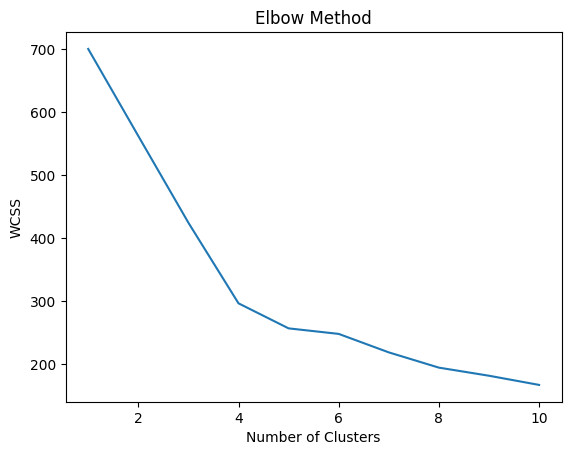

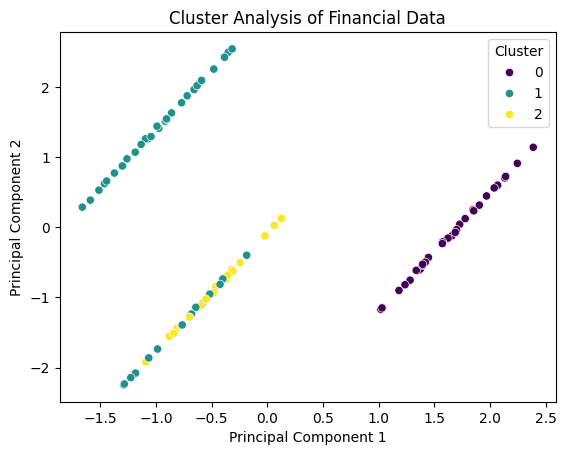

         TransactionAmount        Age         Income
Cluster                                             
0             15218.531250  43.312500  101102.062500
1             15033.577778  42.044444  108641.311111
2             15082.000000  43.173913  110472.391304


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv("financial_data.csv")

data.dropna(inplace=True)
data.drop(['CustomerID'], axis=1, inplace=True)

features = ['TransactionAmount', 'InvestmentType', 'Age', 'Income']
X = data[features]

X = pd.get_dummies(X, columns=['InvestmentType'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dimensionality reduction using PCA (optional)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Determine optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means clustering with optimal number of clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(X_scaled)
data['Cluster'] = kmeans.labels_

# Visualize clusters
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=data['Cluster'],
    palette='viridis'
)
plt.title('Cluster Analysis of Financial Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Interpretation
cluster_summary = data.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)
